# Confusion Matrix

In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix

df = pd.read_csv("tornet_validation_predictions_6thrun.csv")

cm = confusion_matrix(df["true_label"], df["predicted_label"])

print(cm)

[[251  54]
 [ 28  18]]


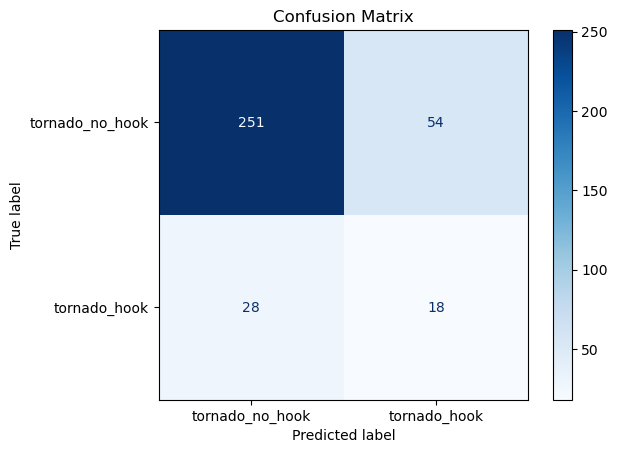

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    df["true_label"],
    df["predicted_label"],
    display_labels=["tornado_no_hook", "tornado_hook"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Model Summary

## Combine all runs

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

files = [
    "tornet_validation_predictions_2ndrun.csv",
    "tornet_validation_predictions_3rdrun.csv",
    "tornet_validation_predictions_4thrun.csv",
    "tornet_validation_predictions_5thrun.csv",
    "tornet_validation_predictions_6thrun.csv"
]

dfs = []

for i, f in enumerate(files):
    df = pd.read_csv(f)
    df["run"] = i + 1
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

## Mean Confusion Matrix

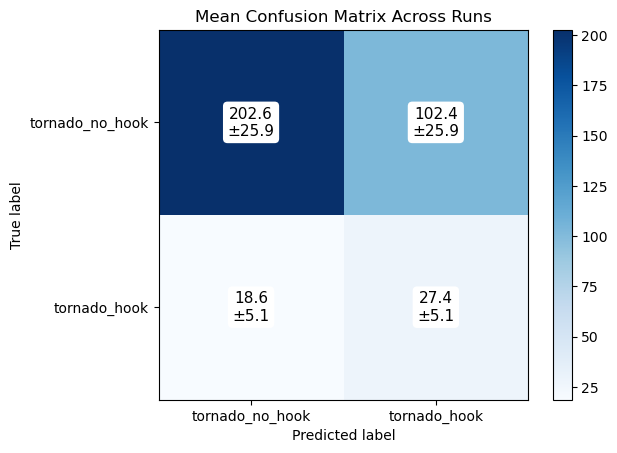

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cms = []

for f in files:
    df = pd.read_csv(f)
    cm = confusion_matrix(df["true_label"], df["predicted_label"])
    cms.append(cm)

cms = np.array(cms)

mean_cm = cms.mean(axis=0)
std_cm = cms.std(axis=0)

fig, ax = plt.subplots()

disp = ConfusionMatrixDisplay(
    confusion_matrix=mean_cm,
    display_labels=["tornado_no_hook", "tornado_hook"]
)

# Turn off built-in numeric labels
disp.plot(cmap="Blues", ax=ax, values_format="")

# Add our own formatted labels
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        ax.text(
            j, i,
            f"{mean_cm[i,j]:.1f}\n±{std_cm[i,j]:.1f}",
            ha="center",
            va="center",
            color="black" if mean_cm[i,j] > mean_cm.max()/2 else "black",
            fontsize=11,
            bbox=dict(
                facecolor="white",   # mask color
                edgecolor="none",
                boxstyle="round,pad=0.3"
            )
        )

plt.title("Mean Confusion Matrix Across Runs")
plt.show()

## Mean ROC

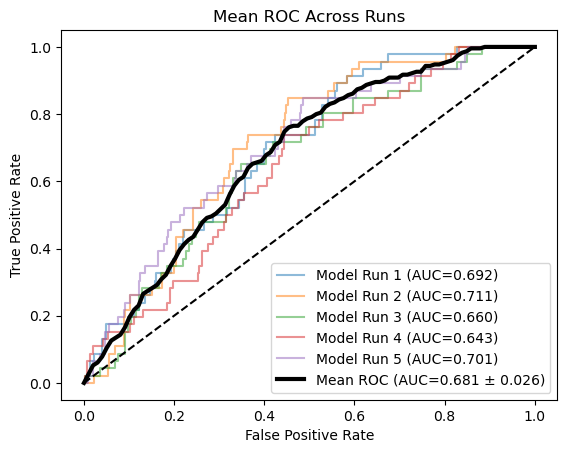

In [28]:
mean_fpr = np.linspace(0,1,100)

tprs = []
aucs = []

plt.figure()

for i, f in enumerate(files):

    df = pd.read_csv(f)

    fpr, tpr, _ = roc_curve(df["true_label"], df["hook_probability"])
    roc_auc = auc(fpr, tpr)

    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0
    tprs.append(interp_tpr)

    run_name = f"Model Run {i+1}"

    plt.plot(
        fpr,
        tpr,
        alpha=0.5,
        label=f"{run_name} (AUC={roc_auc:.3f})"
    )

mean_tpr = np.mean(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.plot(
    mean_fpr,
    mean_tpr,
    linewidth=3,
    color="black",
    label=f"Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Across Runs")

plt.legend()
plt.show()

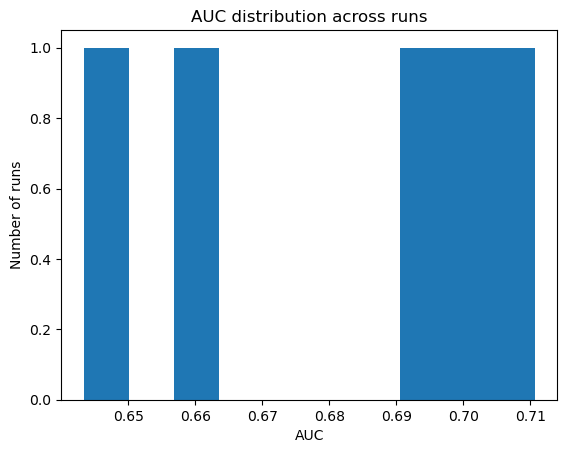

In [25]:
import matplotlib.pyplot as plt

plt.hist(auc_scores)
plt.xlabel("AUC")
plt.ylabel("Number of runs")
plt.title("AUC distribution across runs")
plt.show()

## Probability Distribution

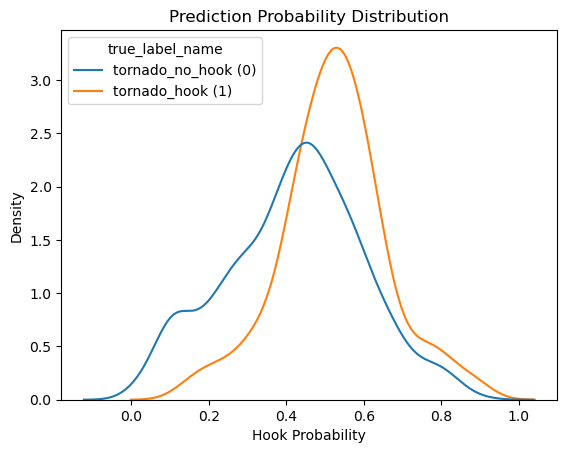

In [27]:
combined["true_label_name"] = combined["true_label"].map({
    0: "tornado_no_hook (0)",
    1: "tornado_hook (1)"
})

import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=combined,
    x="hook_probability",
    hue="true_label_name",
    common_norm=False
)

plt.title("Prediction Probability Distribution")
plt.xlabel("Hook Probability")
plt.show()

## Case-consistency

In [11]:
case_summary = (
    combined
    .groupby(["filepath","frame_idx"])
    .agg(
        true_label=("true_label","first"),
        mean_prediction=("predicted_label","mean"),
        mean_probability=("hook_probability","mean"),
        std_probability=("hook_probability","std"),
        n_runs=("run","count")
    )
    .reset_index()
)

print(case_summary.head())

                                            filepath  frame_idx  true_label  \
0  s3://ml-cloud-project-data/tornet_2013/train/2...          3           0   
1  s3://ml-cloud-project-data/tornet_2013/train/2...          1           0   
2  s3://ml-cloud-project-data/tornet_2013/train/2...          2           0   
3  s3://ml-cloud-project-data/tornet_2013/train/2...          3           0   
4  s3://ml-cloud-project-data/tornet_2013/train/2...          1           0   

   mean_prediction  mean_probability  std_probability  n_runs  
0              0.0          0.192898         0.119268       5  
1              0.6          0.535550         0.145690       5  
2              0.6          0.543733         0.163812       5  
3              0.6          0.551175         0.183625       5  
4              0.4          0.591246         0.200452       5  


In [12]:
uncertain_cases = case_summary.sort_values("std_probability", ascending=False)

print(uncertain_cases.head(20))

                                              filepath  frame_idx  true_label  \
135  s3://ml-cloud-project-data/tornet_2017/train/2...          1           0   
4    s3://ml-cloud-project-data/tornet_2013/train/2...          1           0   
259  s3://ml-cloud-project-data/tornet_2020/train/2...          3           0   
274  s3://ml-cloud-project-data/tornet_2021/train/2...          3           0   
162  s3://ml-cloud-project-data/tornet_2017/train/2...          3           0   
182  s3://ml-cloud-project-data/tornet_2018/train/2...          2           0   
241  s3://ml-cloud-project-data/tornet_2020/train/2...          2           0   
273  s3://ml-cloud-project-data/tornet_2020/train/2...          0           0   
254  s3://ml-cloud-project-data/tornet_2020/train/2...          3           0   
168  s3://ml-cloud-project-data/tornet_2018/train/2...          2           0   
3    s3://ml-cloud-project-data/tornet_2013/train/2...          3           0   
93   s3://ml-cloud-project-d